# Notebook 1 - Introduction to Scikit-Learn
---
*Christian Jelo R. Artoza*

Notes I took from the book *Python Data Science Handbook* by Vanderplas. I'm currently reading Chapter 5, which is supposed to be an introduction to machine learning. It introduces some of the basic machine learning models, going in-depth with a couple of classification, regression, clustering, and dimensional reduction models. I've decided to follow this one along with the machine learning course I'm taking; since machine learning is one of, if not, the most important subject.

## Data Representation in Scikit-Learn

### Data as table

In [2]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Each row pertains to an observed flower. Rows are referred to as *samples*, and the total number of samples is referred to as `n_samples`

The columns represents the aspects of the observed flower and are referred to as the *features*. The number of columns are called `n_features`

### Features Matrix

Information that are formatted this way can be thought of as a two-dimensional array/matrix.

We will call such two-dimensional arrays as a *Features matrix* with shape `[n_sample, n_features]`, and we usually stored in the variable `X`.

Feature matrices are often contained in a Pandas `DataFrame` (the case for the above example) or a Numpy array.

### Target Array

In addition to the features matrix `X`, we also usually work with a *target array* which we denote with `y`.

A target array is usually contained in a Pandas `Series` or a Numpy array. elements of the target array can be continuous numerical values or discrete categorical values (labels).

A target array is most often one-dimensional; however, Scikit-Learn does have capabilities to work on two-dimensional target arrays.

**Important**: A target array represents the quantity we want to predict/optimize (the dependent variable). For example, in the laptop sales data set we used in Course 7, we had the target array `price`.

In the `iris` dataset, the `species` column is our target array.

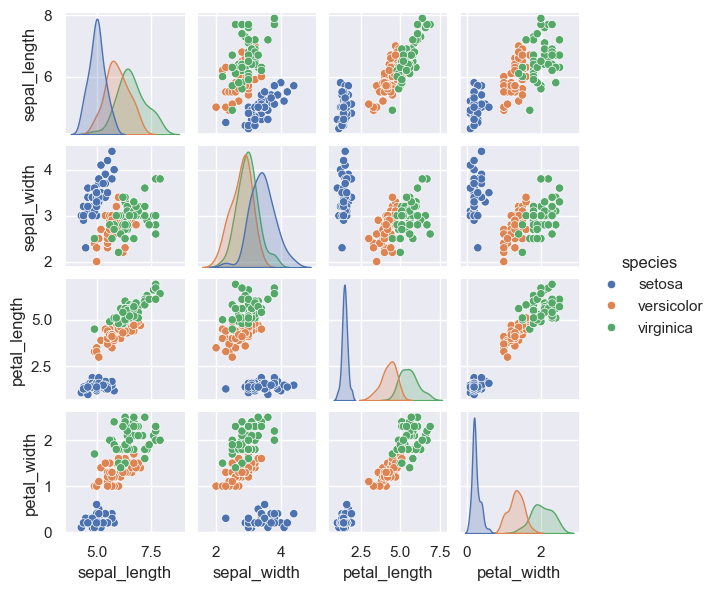

In [3]:
%matplotlib inline
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
sns.pairplot(iris, hue='species', height=1.5)

plt.show()

The above code provides an easy way to see the relationship between each feature (e.g. `sepal_length`, `petal_width`). The colors represent the target array `species`.

To be able to use Scikit-Learn, we need to format the data properly. And the proper format is a features matrix `X` and the target array `y` in the dataframe, both with the same number of samples.

So, it would be good for us to separate a dataframe into `X` and `y` before working with them using Scikit-Learn.

In [4]:
# Features matrix - as Pandas DataFrame
X_iris = iris.drop('species', axis=1)

# Target array - as Pandas Series
y_iris = iris['species']

print('Shapes:')
print('  features matrix:  ', X_iris.shape)
print('  target array:     ', y_iris.shape)

Shapes:
  features matrix:   (150, 4)
  target array:      (150,)


## Scikit-Learn's Estimator API

### Basics of the API
The steps in using the *estimator* API are as follows:
1. Choose a class of model
2. Choose hyperparameters for the model of choice
3. Arrange the data into a features matrix `X` and a target array `y`.
4. Use the method `fit()` to train the model against the data.
5. Use the trained model against new data:
   - For supervised learning, we use `Predict()` to predict labels of newly observed data.
   - For unsupervised learning, we transform or infer properties of newly observed data using `Transform()` or `Predict()`.

### Supervised learning example: Simple linear regression

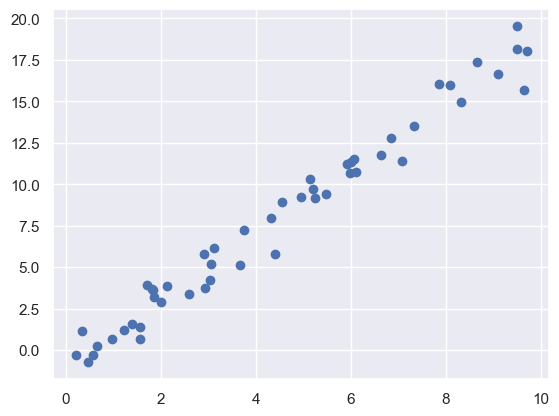

In [5]:
import numpy as np

#Pseudo Random Number Generator
rng = np.random.RandomState(42)

# rng.rand(50) generates an array of 50 samples from a uniform distribution of [0,1]
x = 10 * rng.rand(50) 

# rng.randn(50) generates 50 samples from the normal distribution
y = 2 * x - 1 + rng.randn(50)

plt.scatter(x,y)
plt.show()

#### 1. Choose a class of model
Every model is a class in Scikit-Learn. Once, we have a model in mind, we can import that model as a class.

In [6]:
# In this example we'll be using the LinearRegression model class

from sklearn.linear_model import LinearRegression

#### 2. Choose model hyperparameters
Create an instance of the model and pass the hyperparameters of choice in the instance.

A couple of hyperparameters that we would like to consider are for the following purposes:
1. Fitting for the offset (i.e., intercept)
2. Normalization -- to ensure features are at the same scale
3. Pre-processing of features to add model flexibility
4. Degree of regularization -- constraints/penalties to prevent overfitting and underfitting
5. Specifying how many components to keep (probably gonna learn more about this later...)

In [7]:
# We want to fit for the offset
# So we create an instance of the LinearRegression model class
# and pass the hyperparameter to fit for the offset

model = LinearRegression(fit_intercept=True)
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 3. Arrange data into features matrix `X` and target array `y`

In our case, the target array is `y` and we already defined that in the correct format. But we have to convert `x` into a two-dimensional matrix; it is currently one-dimensional (just a vector).

In [8]:
# We can increase the dimension of x by one unit with np.newaxis

X = x[:, np.newaxis]
print('dimensions of x:                 ', x.shape)
print('dimensions of features matrix X: ', X.shape)

dimensions of x:                  (50,)
dimensions of features matrix X:  (50, 1)


#### 4. Fit the model to the data
For this, we use the `fit()` method. This causes some internal computations to take place; the result of the computations are then stored as attributes of the model.

By convention, the names of the attributes have trailing underscores.

In [9]:
# Fit the model using fit()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Results are stored as attributes of `model`
# The slope of the regression line is saved to the `coef_` attribute
# The intercept is saved to the `intercept_` attribute

print('Regression Line')
print(f' slope:    {model.coef_}')
print(f' intercept {model.intercept_}')

Regression Line
 slope:    [1.9776566]
 intercept -0.903310725531111


#### 5. Predict labels for unknown data
Now for the main task, evaluating the model by testing it against data that were not part of the data used for training.

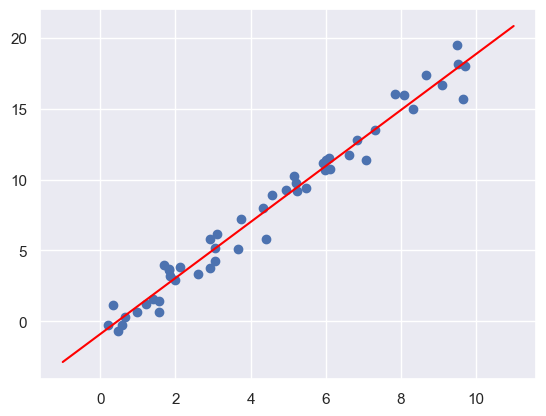

In [11]:
# Our model was fitted to points between 0 and 10.
# We'll evaluate the model by checking its values on points outside that range
# Let's try [-1,0] and [10,11)

xfit = np.linspace(-1,11)  #define the test set
Xfit = xfit[:, np.newaxis] #similar to the x data used for training, we have to make it 2d
yfit = model.predict(Xfit) #predict values for xfit

# Create a plot
plt.scatter(x,y)
plt.plot(xfit,yfit,color='red')
plt.show()

### Supervised learning example: Iris classification

*Question:* Given a model trained on a portion of the Iris dataset, how well can the model predict the labels of the remaining portion?

For this task, we will use the *Gaussian naive Bayes*. It is quick and there are no hyperparameters to specify. It is often a good model to use as a baseline classification.

In [12]:
# 1. Class of model - Gaussian naive Bayes
from sklearn.naive_bayes import GaussianNB

# 2. No hyperparameters needed, but we still have to create an instance
model = GaussianNB()

# 3. Split up the dataset into a training set and a test set using the train_test_split class
# this was discussed in course 7
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris, random_state=1)

# 4. Fit the model to the training set
model.fit(Xtrain,ytrain)

# 5. Predict labels of the test data
y_model = model.predict(Xtest)

for i in range(0,ytest.shape[0]):
    if ytest.values[i] != y_model[i]:
        print('actual value:    ', str(ytest.values[i]))
        print('predicted value: ', str(y_model[i]))

iris.loc[[84],:]

actual value:     versicolor
predicted value:  virginica


,sepal_length,sepal_width,petal_length,petal_width,species
84,5.4,3.0,4.5,1.5,versicolor


As we can see from the result, it actually did well for a simple classification model; it made correct predictions for most of it except for one.

A better way to evaluate the model is to use the `accuracy_score` function. This outputs the fraction of predicted labels that match the actual.

In [13]:
from sklearn.metrics import accuracy_score
print('accuracy score: ', accuracy_score(ytest, y_model))

accuracy score:  0.9736842105263158


This tells us that 97.4% of the predicted labels match the actual.

### Unsupervised learning example: Iris dimensionality

In this example, the goal is to reduce the dimensionality of the iris dataset so as to visualize it better. We can accomplish this using principal component analysis.

In [14]:
# 1. Model class
from sklearn.decomposition import PCA

# 2. Create an instance and select hyperparameters
# In this case, we want two dimensions, so we set the hyperparameter `n_components` equal to 2
model = PCA(n_components=2)

# 3. Arrange the data
# In fitting the PCA model, we only need the features matrix X.
# We want to reduce the dimensions of the features matrix.
X_iris = iris.drop('species', axis=1)

# 4. Fit the model
model.fit(X_iris)

# 5. Use the trained model against the data
# We finally get to our purpose: visualizing the original features matrix by reducing its dimensions
X_2D = model.transform(X_iris)

print("Original features matrix:  ", X_iris.shape)
print("Features matrix after PCA: ", X_2D.shape)

Original features matrix:   (150, 4)
Features matrix after PCA:  (150, 2)


As can be seen, using PCA reduces the dimensions of the features matrix from 4 to 2.

Dimensionality reduction is often used to help visualize the data.

The question now is what did the model do to the data? Can we use this reduced data to predict labels of unknown data? What changed with the reduced data? I don't know yet... In the mean time, imma do some plotting.

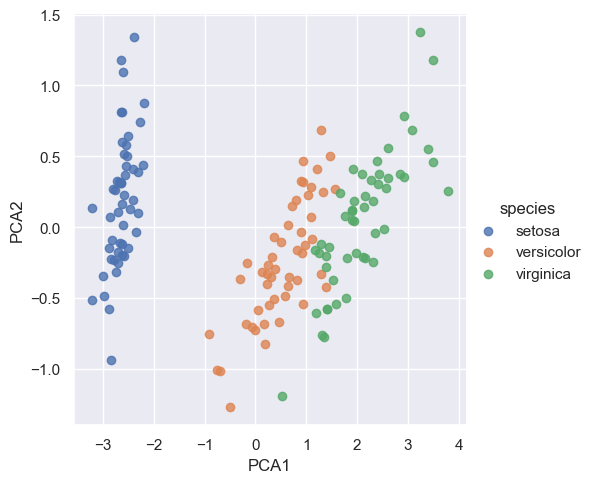

In [15]:
iris['PCA1'] = X_2D[:,0]
iris['PCA2'] = X_2D[:,1]

sns.lmplot(data=iris, x='PCA1', y='PCA2', hue='species', fit_reg=False, ci=None)
plt.show()

It can be seen that the labels in this two-dimensional representation of the data are fairly well separated **without even knowing what the labels are!** (which is what unsupervised learning is all about)

This indicates that we can use a straightforward classification model (aligns with the GaussanNB done earlier)

### Unsupervised learning: Iris clustering

The goal of this example is to apply clustering for predicting labels.

A clustering algorithm attempts to divide data into distinct groups without reference to the actual labels.

In this example, we'll apply the Gaussian Mixture Model to our original features matrix `X_iris`.

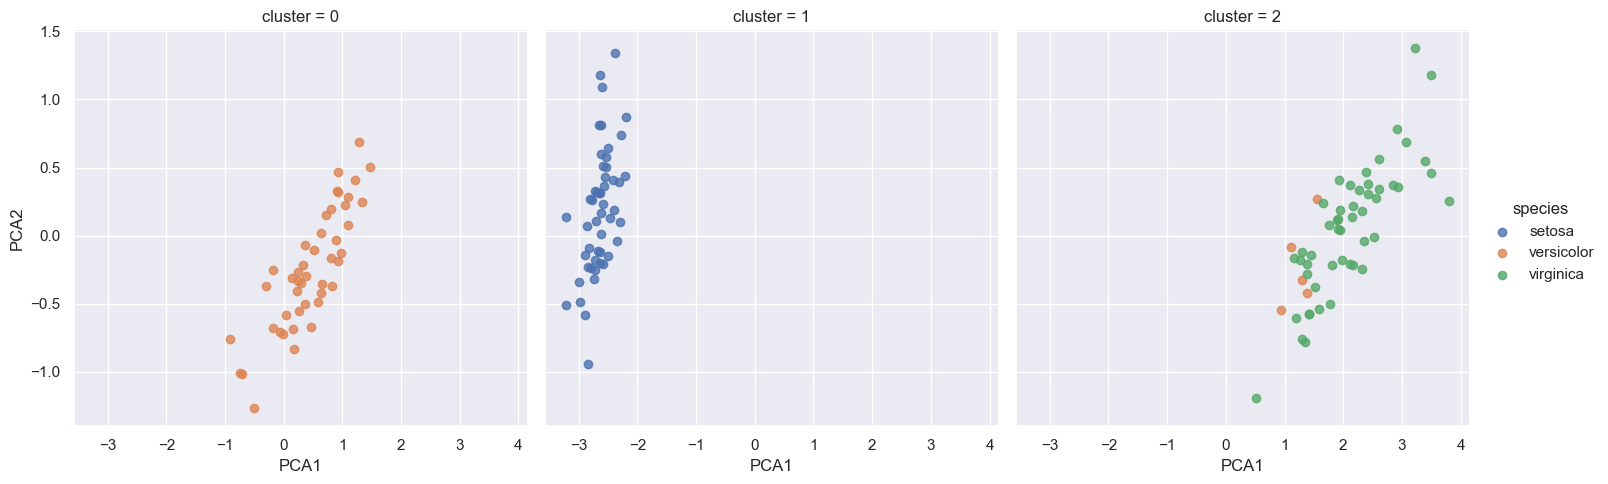

In [16]:
# 1. Model Selection
from sklearn.mixture import GaussianMixture as GMM

# 2. Instantiation and hyperparameter selection
model = GMM(
    n_components = 3, # Divide the dataset into 3 distinct groups
    covariance_type = 'full' # i dont know what this does
)

# 3. Arrange data
X_iris = iris.drop('species', axis=1)

# 4. Fit the model
model.fit(X_iris)

# 5. Use the model to predict labels
# We'll use the two-dimensional representation obtained with PCA to visualize predictions
iris['cluster'] = model.predict(X_iris)
sns.lmplot(
    data = iris,
    x = 'PCA1',
    y = 'PCA2',
    hue = 'species',
    col = 'cluster',
    fit_reg = False,
    ci = None
)
plt.show()

The data was divided into 3 clusters, and each group is plotted separately. `species` is added as the hue of the plots for comparison.

We can see that the model did well in determining the labels for the data. It perfectly identified which flowers are `setosa`; a few `vericolor` flowers were labelled as `virginica` flowers, but other than that the model did pretty well.

It did so without knowing the original labels setosa, vericolor, and virginica -- based only on the features.

### Application: Exploring Handwritten Digits

In [17]:
# Load data - will be using preformatted data from sklearn
from sklearn.datasets import load_digits
digits = load_digits() # digits.images contains the image data, digits.target is the target array
digits.images.shape

(1797, 8, 8)

The image data is a **three-dimensional** array. There are 1797 samples (handwritten digits), and each sample is a 8x8 grid of pixels.

In [18]:
# Example: Sample 1
print('sample 1 image in array format: ')
print(digits.images[0])
print('')
print('label of sample 1: ', digits.target[0])

sample 1 image in array format: 
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

label of sample 1:  0


just know that this array is supposed to represent a handwritten image of the digit '0'. Each element of the array is a pixel of the image.

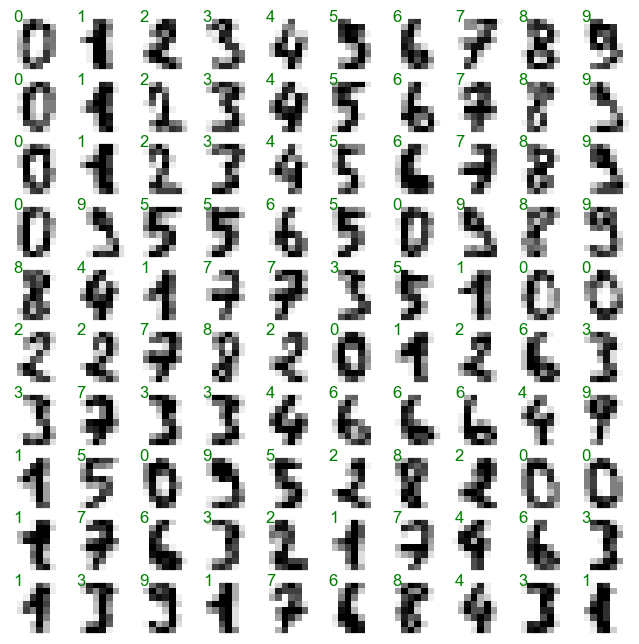

In [19]:
# Visualize the first 100 samples
fig, axes = plt.subplots(
    10, 10, figsize=(8,8),
    subplot_kw = {'xticks': [], 'yticks': []}
)

for i,ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]), color='green')

In order to work with this data in Scikit-Learn, we have to transform it into a `n_samples x n_features` features matrix. This can be done by treating each pixel as a feature. So, for instance, in the sample 1 above, we treat each element of the array representing sample 1 as a feature.

Since each image is a 8x8 grid of pixels, the result is a features matrix with 1797 samples and 64 features (pixel1, pixel2, ..., pixel64).

This transformed data is already available from the preprocessed data.

In [20]:
X = digits.data # the features matrix
y = digits.target # the target array

print('Shapes')
print(' features matrix: ', X.shape)
print(' target array:    ', y.shape)

Shapes
 features matrix:  (1797, 64)
 target array:     (1797,)


#### Unsupervised learning: Dimensionality reduction

Visualize the data using another dimensionality reduction model.

We'll use the manifold learning algorithm called *Isomap* to find a 2d representation of the data.

In [21]:
from sklearn.manifold import Isomap #1. Choose model

#2. Create instance and set hyperparameters
#Similar to the PCA model, specify n_components as 2.
model = Isomap(n_components=2)

#3. We have already prepared the data -- we have features matrix X and target array y

model.fit(X) #4. fit the model
data_projected = model.transform(X) #5. Use the model to transform data
data_projected.shape

/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)

We can then visualize the data

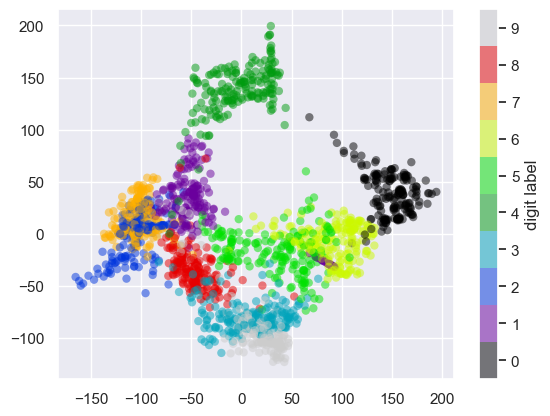

In [22]:
plt.scatter(
    data_projected[:,0],
    data_projected[:,1],
    c = digits.target,
    edgecolor = 'none', alpha = 0.5,
    cmap = plt.get_cmap('nipy_spectral', 10)
)
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5,9.5)
plt.show()

Some sanity checks:
- Samples labelled 0 have the least overlap with the others. This makes sense since zeros don't look like the other digits -- we can easily distinguish a zero from another digit.
- Twos and sevens have a big overlap. Also makes sense -- a handwritten two and seven does look similar especially if one draws a seven without that strikethrough. Their heads would look similar if not written perfectly.

There's plenty more insights we can draw from the plot.

Overall, I think the groups are separated enough that a straightforward model would work with promising results.

#### Classification on Digits

In [23]:
import pandas as pd

X_df = pd.DataFrame(X)
y_df = pd.Series(y)

We'll use the Gaussian naives Bayes classification model, split the data into training and test sets, fit the model to the training data, and finally predict labels for the test data.

In [24]:
model = GaussianNB()
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, random_state=0)
model.fit(X_train, y_train)
y_model = model.predict(X_test)

Examine model accuracy with the Scikit-Learn's `accuracy_score()` function

In [26]:
print('Accuracy score: ', accuracy_score(y_test, y_model))

Accuracy score:  0.8333333333333334


Fairly good, but the model still has some room for improvement.

The accuracy score does not really tell us where the model fails. One way to see this is to generate the `confusion_matrix`.

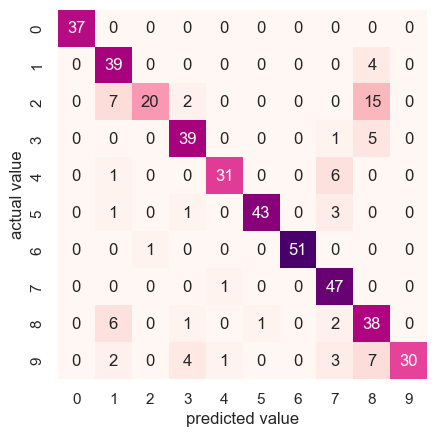

In [27]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, y_model)
sns.heatmap(mat, square=True, annot=True, cbar=False, cmap='RdPu')
plt.xlabel('predicted value')
plt.ylabel('actual value')
plt.show()

Based on the confusion matrix, plenty of handwritten twos are misclassified by the model as a ones or eights.

7 samples have actual labels of '2' but have predicted labels of '1'.

Similarly, 15 samples are actually twos, but the model predicted them as being eights.

Another way to check the model is by plotting the inputs as before and displaying their labels as predicted by the model. The displayed label is colored green if the model predicted right, `y_model == y_test`; otherwise, it displays the label in red.

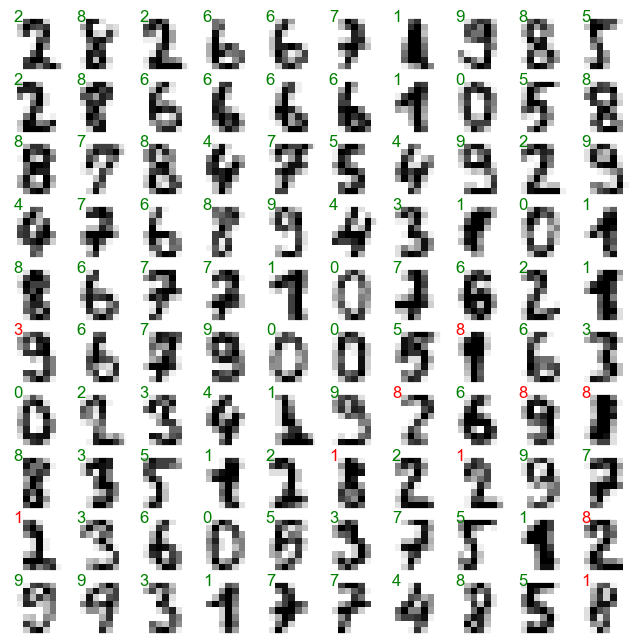

In [28]:
fig, axes = plt.subplots(
    10, 10, figsize=(8,8),
    subplot_kw = {'xticks': [], 'yticks': []}
)

images = [digits.images[i] for i in X_test.index]
for i,ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(y_model[i]),
            color='green' if (y_model[i]==y_test.to_numpy()[i]) else 'red')

From our examination, we can see that the model does not perform optimally on handwritten twos, mostly. To address this, it might be better to consider more sophisticated models.